In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 1. Imports and configuration

In [2]:
import os
import numpy as np
import pandas as pd
import requests
import matplotlib.pyplot as plt

WEATHER_COLS = [
    "ALLSKY_SFC_SW_DWN",
    "T2M",
    "WS2M",
    "RH2M",
]

In [3]:
class SolarGenerationSimulationPipeline:
    def __init__(
        self,
        lookup_path,
        years_history=10,
        n_scenarios=50,
        doy_window=3,
        pr=0.80,
        temp_coeff=-0.0035,
        soiling_loss=0.00,
        degradation_loss=0.00,
        random_state=42,
        nasa_timeout=60,
    ):
        self.lookup_path = lookup_path
        self.lookup_df = pd.read_csv(lookup_path)

        self.years_history = years_history
        self.n_scenarios = n_scenarios
        self.doy_window = doy_window

        self.pr = pr
        self.temp_coeff = temp_coeff
        self.soiling_loss = soiling_loss
        self.degradation_loss = degradation_loss

        self.random_state = random_state
        self.nasa_timeout = nasa_timeout

        self.weather_cols = [
            "ALLSKY_SFC_SW_DWN",
            "T2M",
            "WS2M",
            "RH2M",
        ]

        self._validate_lookup_table()

    def _validate_lookup_table(self):
        required_cols = ["postcode", "solar_ref_id", "ref_lat", "ref_long"]
        missing_cols = [col for col in required_cols if col not in self.lookup_df.columns]

        if missing_cols:
            raise ValueError(f"Missing columns in lookup table: {missing_cols}")

        self.lookup_df["postcode"] = self.lookup_df["postcode"].astype(int)
        self.lookup_df["solar_ref_id"] = self.lookup_df["solar_ref_id"].astype(str)
        self.lookup_df["ref_lat"] = self.lookup_df["ref_lat"].astype(float)
        self.lookup_df["ref_long"] = self.lookup_df["ref_long"].astype(float)

        duplicated = self.lookup_df["postcode"].duplicated().sum()
        if duplicated > 0:
            raise ValueError(
                f"Lookup table must contain one row per postcode, "
                f"but found {duplicated} duplicated postcode rows."
            )

    def get_station_from_postcode(self, postcode):
        postcode = int(postcode)

        row = self.lookup_df[self.lookup_df["postcode"] == postcode]

        if row.empty:
            raise ValueError(f"Postcode {postcode} not found in lookup table.")

        row = row.iloc[0]

        station_info = {
            "postcode": postcode,
            "solar_ref_id": row["solar_ref_id"],
            "lat": float(row["ref_lat"]),
            "lon": float(row["ref_long"]),
        }

        if "cluster" in row:
            station_info["cluster"] = row["cluster"]

        if "distance_km" in row:
            station_info["distance_km"] = row["distance_km"]

        return station_info

    def fetch_nasa_power_hourly_clean(self, lat, lon, year_start, year_end):
        base_url = "https://power.larc.nasa.gov/api/temporal/hourly/point"

        all_dfs = []

        print(
            f"Loading NASA POWER hourly weather at ({lat:.4f}, {lon:.4f}) "
            f"from {year_start} to {year_end}..."
        )

        for year in range(year_start, year_end + 1):
            params = {
                "parameters": ",".join(self.weather_cols),
                "community": "RE",
                "longitude": lon,
                "latitude": lat,
                "start": f"{year}0101",
                "end": f"{year}1231",
                "format": "JSON",
            }

            response = requests.get(
                base_url,
                params=params,
                timeout=self.nasa_timeout,
            )

            if response.status_code != 200:
                print(f"Warning: failed to fetch {year}, status={response.status_code}")
                continue

            data = response.json()["properties"]["parameter"]

            df_year = pd.DataFrame(data)
            df_year.index = pd.to_datetime(df_year.index, format="%Y%m%d%H")
            df_year = df_year.sort_index()

            all_dfs.append(df_year)

        if not all_dfs:
            raise ValueError("No NASA POWER weather data was fetched.")

        df = pd.concat(all_dfs).sort_index()

        df = df[self.weather_cols]

        # NASA invalid values
        df.replace([-999, -999.0], np.nan, inplace=True)

        # Clean missing values
        df = df.interpolate(method="linear").ffill().bfill()

        df = df.reset_index().rename(columns={"index": "datetime"})

        df["datetime"] = pd.to_datetime(df["datetime"])
        df["date"] = df["datetime"].dt.normalize()
        df["year"] = df["datetime"].dt.year
        df["month"] = df["datetime"].dt.month
        df["day_of_year"] = df["datetime"].dt.dayofyear
        df["hour"] = df["datetime"].dt.hour

        return df

    @staticmethod
    def circular_doy_distance(doy_a, doy_b):
        diff = abs(int(doy_a) - int(doy_b))
        return min(diff, 366 - diff)

    def simulate_future_weather(self, historical_weather, forecast_start, days=365):
        rng = np.random.default_rng(self.random_state)

        df = historical_weather.copy()
        df["datetime"] = pd.to_datetime(df["datetime"])
        df["date"] = pd.to_datetime(df["date"]).dt.normalize()

        forecast_start = pd.to_datetime(forecast_start).normalize()
        future_dates = pd.date_range(
            start=forecast_start,
            periods=days,
            freq="D",
        )

        available_dates = df["date"].drop_duplicates().sort_values().to_numpy()

        rows = []

        for scenario_id in range(self.n_scenarios):
            for future_date in future_dates:
                target_doy = future_date.dayofyear

                candidate_dates = []

                for hist_date in available_dates:
                    hist_date = pd.Timestamp(hist_date)
                    dist = self.circular_doy_distance(
                        hist_date.dayofyear,
                        target_doy,
                    )

                    if dist <= self.doy_window:
                        candidate_dates.append(hist_date)

                if not candidate_dates:
                    raise ValueError(
                        f"No historical candidates found for {future_date.date()}"
                    )

                sampled_date = pd.Timestamp(rng.choice(candidate_dates)).normalize()

                block = (
                    df[df["date"] == sampled_date]
                    .sort_values("hour")
                    .head(24)
                    .copy()
                )

                if len(block) < 24:
                    continue

                for _, row in block.iterrows():
                    future_datetime = future_date + pd.Timedelta(hours=int(row["hour"]))

                    rows.append({
                        "scenario_id": scenario_id,
                        "datetime": future_datetime,
                        "date": future_date,
                        "hour": int(row["hour"]),
                        "day_of_year": int(future_datetime.dayofyear),
                        "month": int(future_datetime.month),
                        "sampled_date": sampled_date,
                        "ALLSKY_SFC_SW_DWN": float(row["ALLSKY_SFC_SW_DWN"]),
                        "T2M": float(row["T2M"]),
                        "WS2M": float(row["WS2M"]),
                        "RH2M": float(row["RH2M"]),
                    })

        future_weather = pd.DataFrame(rows)

        if future_weather.empty:
            raise ValueError("No future weather scenarios were generated.")

        return future_weather.sort_values(
            ["scenario_id", "datetime"]
        ).reset_index(drop=True)

    def calculate_solar_from_weather(self, weather_scenarios, capacity_kwp):
        df = weather_scenarios.copy()

        effective_pr = (
            self.pr
            * (1 - self.soiling_loss)
            * (1 - self.degradation_loss)
        )

        # NOCT-based cell temperature approximation
        # T_cell = T_ambient + (G / 800) * (NOCT - 20)
        # Assume NOCT = 45°C, so NOCT - 20 = 25
        df["T_cell"] = df["T2M"] + (df["ALLSKY_SFC_SW_DWN"] / 800.0 * 25.0)

        df["temp_factor"] = 1 + self.temp_coeff * (df["T_cell"] - 25.0)
        df["temp_factor"] = df["temp_factor"].clip(lower=0)

        # ALLSKY_SFC_SW_DWN is assumed to be Wh/m², so divide by 1000
        df["solar_gen_kwh"] = (
            (df["ALLSKY_SFC_SW_DWN"] / 1000.0)
            * capacity_kwp
            * df["temp_factor"]
            * effective_pr
        ).clip(lower=0)

        return df

    def aggregate_forecast(self, scenario_generation):
        forecast_df = (
            scenario_generation
            .groupby("datetime")["solar_gen_kwh"]
            .quantile([0.1, 0.5, 0.9])
            .unstack()
            .reset_index()
            .rename(columns={
                0.1: "q0.1",
                0.5: "q0.5",
                0.9: "q0.9",
            })
        )

        forecast_df["datetime"] = pd.to_datetime(forecast_df["datetime"])
        forecast_df["date"] = forecast_df["datetime"].dt.normalize()
        forecast_df["year"] = forecast_df["datetime"].dt.year
        forecast_df["month"] = forecast_df["datetime"].dt.month
        forecast_df["hour"] = forecast_df["datetime"].dt.hour

        return forecast_df

    def build_monthly_forecast(self, hourly_forecast):
        df = hourly_forecast.copy()
        df["period"] = df["datetime"].dt.to_period("M").astype(str)

        monthly_df = (
            df.groupby("period")[["q0.1", "q0.5", "q0.9"]]
            .sum()
            .reset_index()
        )

        return monthly_df

    def plot_hourly_forecast(self, hourly_forecast, title=None):
        df = hourly_forecast.copy()

        if title is None:
            title = "Hourly Solar Generation Forecast"

        plt.figure(figsize=(16, 6))
        plt.plot(
            df["datetime"],
            df["q0.5"],
            label="Median forecast (q0.5)",
        )
        plt.fill_between(
            df["datetime"],
            df["q0.1"],
            df["q0.9"],
            alpha=0.2,
            label="Prediction interval (q0.1-q0.9)",
        )
        plt.title(title)
        plt.xlabel("Datetime")
        plt.ylabel("Solar generation (kWh)")
        plt.legend()
        plt.grid(True)
        plt.show()

    def plot_monthly_forecast(self, monthly_forecast, title=None):
        df = monthly_forecast.copy()

        if title is None:
            title = "Monthly Solar Generation Forecast"

        yerr_lower = df["q0.5"] - df["q0.1"]
        yerr_upper = df["q0.9"] - df["q0.5"]

        plt.figure(figsize=(14, 6))
        plt.bar(
            df["period"],
            df["q0.5"],
            yerr=[yerr_lower, yerr_upper],
            capsize=4,
        )
        plt.title(title)
        plt.xlabel("Month")
        plt.ylabel("Solar generation (kWh)")
        plt.xticks(rotation=45)
        plt.grid(axis="y")
        plt.show()

    def run(
        self,
        postcode,
        capacity_kwp,
        forecast_start=None,
        days=365,
        save_outputs=True,
        output_dir="/content/drive/MyDrive/simulation_outputs",
        plot=True,
    ):
        """
        Main inference function.

        Input:
        - postcode
        - capacity_kwp

        Output:
        - hourly solar generation forecast for the next 365 days
        """

        station = self.get_station_from_postcode(postcode)

        print("Selected station:")
        print(f"Postcode     : {station['postcode']}")
        print(f"Solar ref ID : {station['solar_ref_id']}")
        print(f"Ref lat/lon  : {station['lat']:.6f}, {station['lon']:.6f}")

        if forecast_start is None:
            forecast_start = pd.Timestamp.today().normalize()
        else:
            forecast_start = pd.to_datetime(forecast_start).normalize()

        forecast_end = forecast_start + pd.Timedelta(days=days - 1)

        year_end = forecast_start.year - 1
        year_start = year_end - self.years_history + 1

        print("Date range:")
        print(f"Historical weather: {year_start} -> {year_end}")
        print(f"Forecast          : {forecast_start.date()} -> {forecast_end.date()}")

        # 1. Fetch and clean historical weather
        historical_weather = self.fetch_nasa_power_hourly_clean(
            lat=station["lat"],
            lon=station["lon"],
            year_start=year_start,
            year_end=year_end,
        )

        historical_weather["solar_ref_id"] = station["solar_ref_id"]

        # 2. Simulate future weather for the next 365 days
        future_weather_scenarios = self.simulate_future_weather(
            historical_weather=historical_weather,
            forecast_start=forecast_start,
            days=days,
        )

        future_weather_scenarios["solar_ref_id"] = station["solar_ref_id"]

        # 3. Calculate solar generation from simulated future weather
        scenario_generation = self.calculate_solar_from_weather(
            weather_scenarios=future_weather_scenarios,
            capacity_kwp=capacity_kwp,
        )

        scenario_generation["postcode"] = station["postcode"]
        scenario_generation["solar_ref_id"] = station["solar_ref_id"]
        scenario_generation["capacity_kwp"] = capacity_kwp

        # 4. Aggregate q0.1, q0.5, q0.9
        hourly_forecast = self.aggregate_forecast(scenario_generation)

        hourly_forecast["postcode"] = station["postcode"]
        hourly_forecast["solar_ref_id"] = station["solar_ref_id"]
        hourly_forecast["capacity_kwp"] = capacity_kwp

        # 5. Monthly forecast
        monthly_forecast = self.build_monthly_forecast(hourly_forecast)

        monthly_forecast["postcode"] = station["postcode"]
        monthly_forecast["solar_ref_id"] = station["solar_ref_id"]
        monthly_forecast["capacity_kwp"] = capacity_kwp

        # 6. Save outputs
        if save_outputs:
            os.makedirs(output_dir, exist_ok=True)

            prefix = f"solar_sim_{station['postcode']}_{capacity_kwp}kwp_{forecast_start.year}"

            hourly_path = os.path.join(output_dir, f"{prefix}_hourly_forecast.csv")
            monthly_path = os.path.join(output_dir, f"{prefix}_monthly_forecast.csv")
            scenarios_path = os.path.join(output_dir, f"{prefix}_scenario_generation.csv")

            hourly_forecast.to_csv(hourly_path, index=False)
            monthly_forecast.to_csv(monthly_path, index=False)
            scenario_generation.to_csv(scenarios_path, index=False)

            print(f"Saved hourly forecast  -> {hourly_path}")
            print(f"Saved monthly forecast -> {monthly_path}")
            print(f"Saved scenario output  -> {scenarios_path}")

        # 7. Plot
        if plot:
            title_prefix = (
                f"Solar Generation Forecast {forecast_start.year} — "
                f"Postcode {station['postcode']}, {capacity_kwp} kWp"
            )

            self.plot_hourly_forecast(
                hourly_forecast,
                title=f"{title_prefix} hourly forecast",
            )

            self.plot_monthly_forecast(
                monthly_forecast,
                title=f"{title_prefix} monthly forecast",
            )

        return {
            "station": station,
            "hourly_forecast": hourly_forecast,
            "monthly_forecast": monthly_forecast,
            "future_weather_scenarios": future_weather_scenarios,
            "scenario_generation": scenario_generation,
        }

In [4]:
lookup_path = "/content/drive/MyDrive/TT/data/postcode_to_solar_ref_lookup.csv"

pipeline = SolarGenerationSimulationPipeline(
    lookup_path=lookup_path,
    years_history=10,
    n_scenarios=50,
    doy_window=3,
    pr=0.80,
    temp_coeff=-0.0035,
    soiling_loss=0.00,
    degradation_loss=0.00,
    random_state=42,
)

Selected station:
Postcode     : 2000
Solar ref ID : AUS_SOLAR_REF_051
Ref lat/lon  : -33.812636, 151.214797
Date range:
Historical weather: 2016 -> 2025
Forecast          : 2026-05-18 -> 2027-05-17
Loading NASA POWER hourly weather at (-33.8126, 151.2148) from 2016 to 2025...
Saved hourly forecast  -> /content/drive/MyDrive/simulation_outputs/solar_sim_2000_6.6kwp_2026_hourly_forecast.csv
Saved monthly forecast -> /content/drive/MyDrive/simulation_outputs/solar_sim_2000_6.6kwp_2026_monthly_forecast.csv
Saved scenario output  -> /content/drive/MyDrive/simulation_outputs/solar_sim_2000_6.6kwp_2026_scenario_generation.csv


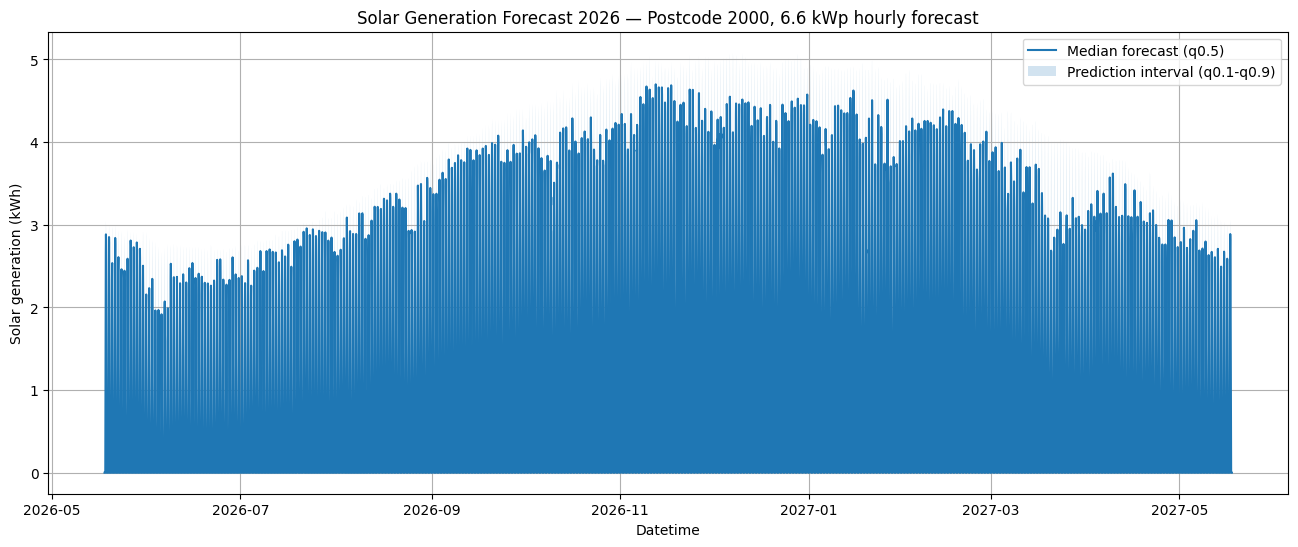

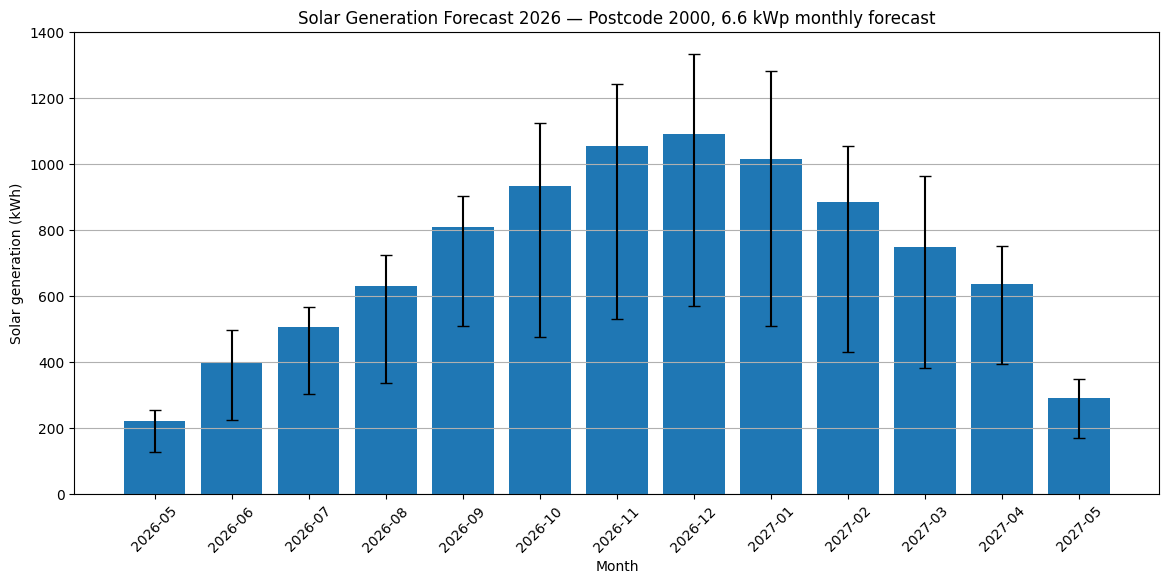

In [6]:
outputs = pipeline.run(
    postcode=2000,
    capacity_kwp=6.6,
    # forecast_start="2026-01-01",
    # days=365,
    # save_outputs=True,
    # output_dir="/content/drive/MyDrive/simulation_outputs",
    plot=True,
)

In [7]:
hourly_forecast = outputs["hourly_forecast"]
monthly_forecast = outputs["monthly_forecast"]

hourly_forecast.head()

,datetime,q0.1,q0.5,q0.9,date,year,month,hour,postcode,solar_ref_id,capacity_kwp
0,2026-05-18 00:00:00,0.0,0.0,0.0,2026-05-18,2026,5,0,2000,AUS_SOLAR_REF_051,6.6
1,2026-05-18 01:00:00,0.0,0.0,0.0,2026-05-18,2026,5,1,2000,AUS_SOLAR_REF_051,6.6
2,2026-05-18 02:00:00,0.0,0.0,0.0,2026-05-18,2026,5,2,2000,AUS_SOLAR_REF_051,6.6
3,2026-05-18 03:00:00,0.0,0.0,0.0,2026-05-18,2026,5,3,2000,AUS_SOLAR_REF_051,6.6
4,2026-05-18 04:00:00,0.0,0.0,0.0,2026-05-18,2026,5,4,2000,AUS_SOLAR_REF_051,6.6


Hourly solar generation forecast for 2026-05-19
Number of hourly records: 24


,datetime,hour,q0.1,q0.5,q0.9
24,2026-05-19 00:00:00,0,0.000000,0.000000,0.000000
25,2026-05-19 01:00:00,1,0.000000,0.000000,0.000000
26,2026-05-19 02:00:00,2,0.000000,0.000000,0.000000
27,2026-05-19 03:00:00,3,0.000000,0.000000,0.000000
28,2026-05-19 04:00:00,4,0.000000,0.000000,0.000000
29,2026-05-19 05:00:00,5,0.000000,0.000000,0.000000
30,2026-05-19 06:00:00,6,0.000000,0.000000,0.000000
31,2026-05-19 07:00:00,7,0.303888,0.447898,0.521263
32,2026-05-19 08:00:00,8,0.831555,1.252672,1.405223
33,2026-05-19 09:00:00,9,1.345767,2.029811,2.196888


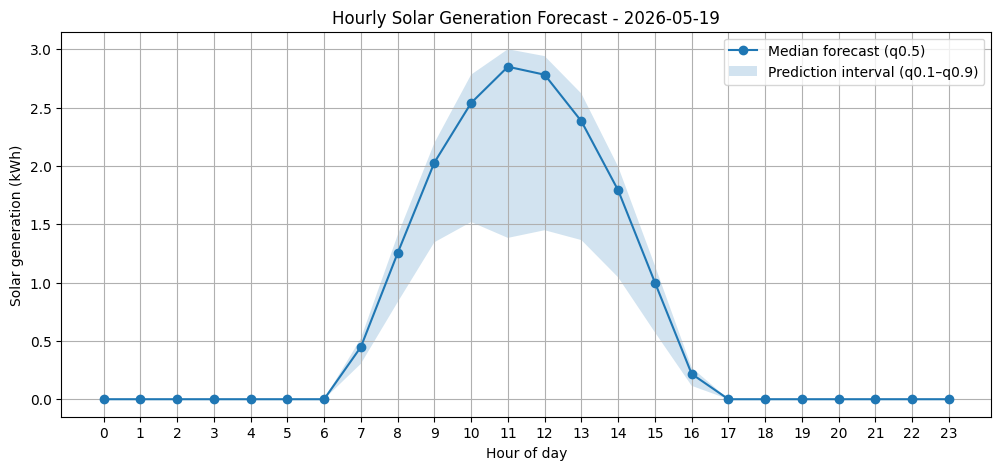

In [9]:
def show_one_day_hourly_forecast(hourly_forecast, date=None, plot=True):
    """
    Show hourly solar generation forecast for one day.

    Parameters
    ----------
    hourly_forecast : pd.DataFrame
        Output dataframe from pipeline["hourly_forecast"].
        Expected columns: datetime, q0.1, q0.5, q0.9.

    date : str or None
        Date to display, e.g. "2026-01-01".
        If None, the first date in hourly_forecast is used.

    plot : bool
        Whether to plot the hourly forecast.
    """

    df = hourly_forecast.copy()
    df["datetime"] = pd.to_datetime(df["datetime"])
    df["date"] = df["datetime"].dt.date
    df["hour"] = df["datetime"].dt.hour

    if date is None:
        target_date = df["date"].min()
    else:
        target_date = pd.to_datetime(date).date()

    day_df = df[df["date"] == target_date].copy()

    if day_df.empty:
        raise ValueError(f"No forecast data found for date: {target_date}")

    day_df = day_df.sort_values("hour")

    display_cols = ["datetime", "hour", "q0.1", "q0.5", "q0.9"]

    print(f"Hourly solar generation forecast for {target_date}")
    print(f"Number of hourly records: {len(day_df)}")

    display(day_df[display_cols])

    if plot:
        plt.figure(figsize=(12, 5))

        plt.plot(
            day_df["hour"],
            day_df["q0.5"],
            marker="o",
            label="Median forecast (q0.5)"
        )

        plt.fill_between(
            day_df["hour"],
            day_df["q0.1"],
            day_df["q0.9"],
            alpha=0.2,
            label="Prediction interval (q0.1–q0.9)"
        )

        plt.title(f"Hourly Solar Generation Forecast - {target_date}")
        plt.xlabel("Hour of day")
        plt.ylabel("Solar generation (kWh)")
        plt.xticks(range(0, 24))
        plt.grid(True)
        plt.legend()
        plt.show()

    return day_df

day_forecast = show_one_day_hourly_forecast(
    hourly_forecast,
    date="2026-05-19",
    plot=True
)

In [8]:
monthly_forecast.head()

,period,q0.1,q0.5,q0.9,postcode,solar_ref_id,capacity_kwp
0,2026-05,125.974613,222.058464,255.965022,2000,AUS_SOLAR_REF_051,6.6
1,2026-06,224.843951,395.809896,498.647850,2000,AUS_SOLAR_REF_051,6.6
2,2026-07,303.482450,505.424917,568.152330,2000,AUS_SOLAR_REF_051,6.6
3,2026-08,336.051621,629.706508,723.227953,2000,AUS_SOLAR_REF_051,6.6
4,2026-09,508.502823,808.479979,903.071402,2000,AUS_SOLAR_REF_051,6.6
